In [5]:
!git clone https://github.com/clayton-h-costa/pv_fault_dataset.git

fatal: destination path 'pv_fault_dataset' already exists and is not an empty directory.


In [177]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.io import loadmat
warnings.filterwarnings('ignore')

# Set ggplot style
plt.style.use('ggplot')

# ML and Deep Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import shap
import joblib

In [7]:
# Load the dataset
elec_data = loadmat("pv_fault_dataset/dataset_elec.mat")
amb_data  = loadmat("pv_fault_dataset/dataset_amb.mat")

In [8]:
# Extract variables
vdc1 = elec_data['vdc1'].flatten()
vdc2 = elec_data['vdc2'].flatten()
idc1 = elec_data['idc1'].flatten()
idc2 = elec_data['idc2'].flatten()

irr = amb_data['irr'].flatten()
pvt = amb_data['pvt'].flatten()
f_nv = amb_data['f_nv'].flatten()

# Create a DataFrame for easier analysis
df = pd.DataFrame({
    'vdc1': vdc1,
    'vdc2': vdc2,
    'idc1': idc1,
    'idc2': idc2,
    'irradiance': irr,
    'temperature': pvt,
    'fault_label': f_nv
})

df = df[df['fault_label'] != 2].copy()

In [9]:
# View the features
df.head()

,vdc1,vdc2,idc1,idc2,irradiance,temperature,fault_label
0,0.7143,0.5550,0.0608,0.0073,1.3729,2.3816,0
1,0.6944,0.5427,0.0615,0.0064,1.3604,2.3816,0
2,0.7110,0.5583,0.0646,0.0067,1.5118,2.3883,0
3,0.6991,0.5465,0.0628,0.0067,1.5534,2.3920,0
4,0.7035,0.5553,0.0606,0.0076,1.4355,2.3920,0


In [10]:
# Total samples
print("Total samples:", len(df))

Total samples: 1363427


In [11]:
# Label value counts
df['fault_label'].value_counts()

fault_label
0    1162931
4     188473
3       6024
1       5999
Name: count, dtype: int64

In [12]:
# **3. Data Preprocessing**

# Add calculated columns
df['power_string1'] = df['vdc1'] * df['idc1']
df['power_string2'] = df['vdc2'] * df['idc2']
df['total_power'] = df['power_string1'] + df['power_string2']
df['voltage_ratio'] = df['vdc1'] / df['vdc2']
df['current_ratio'] = df['idc1'] / df['idc2']

print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {len(df)}")

# Create fault name mapping
fault_names = {
    0: 'Normal Operation',
    1: 'Short-Circuit',
    3: 'Open Circuit',
    4: 'Shadowing'
}

# Add fault name column
df['fault_label'] = df['fault_label'].map(fault_names)

Dataset shape: (1363427, 12)
Number of samples: 1363427


In [13]:
df.head()

,vdc1,vdc2,idc1,idc2,irradiance,temperature,fault_label,power_string1,power_string2,total_power,voltage_ratio,current_ratio
0,0.7143,0.5550,0.0608,0.0073,1.3729,2.3816,Normal Operation,0.043429,0.004052,0.047481,1.287027,8.328767
1,0.6944,0.5427,0.0615,0.0064,1.3604,2.3816,Normal Operation,0.042706,0.003473,0.046179,1.279528,9.609375
2,0.7110,0.5583,0.0646,0.0067,1.5118,2.3883,Normal Operation,0.045931,0.003741,0.049671,1.273509,9.641791
3,0.6991,0.5465,0.0628,0.0067,1.5534,2.3920,Normal Operation,0.043903,0.003662,0.047565,1.279231,9.373134
4,0.7035,0.5553,0.0606,0.0076,1.4355,2.3920,Normal Operation,0.042632,0.004220,0.046852,1.266883,7.973684


In [14]:
# **4. Train Test Splitting**

# Seperate data
X = df.drop(['fault_label'], axis=1).values
y = df['fault_label'].values

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1363427, 11)
y Shape: (1363427,)


In [46]:
feature_names = df.drop(['fault_label'], axis=1).columns.tolist()
feature_names

['vdc1',
 'vdc2',
 'idc1',
 'idc2',
 'irradiance',
 'temperature',
 'power_string1',
 'power_string2',
 'total_power',
 'voltage_ratio',
 'current_ratio']

In [15]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Show the shapes
print("X train shape:", X_train_scaled.shape)
print("X test shape:", X_test_scaled.shape)

X train shape: (1090741, 11)
X test shape: (272686, 11)


In [18]:
# View total samples
print("Training set:", len(X_train_scaled),"samples")
print("Testing set:", len(X_test_scaled),"samples")

Training set: 1090741 samples
Testing set: 272686 samples


In [19]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class weights:", class_weights)

Class weights: {'Normal Operation': np.float64(0.2931015301866836), 'Open Circuit': np.float64(56.585443037974684), 'Shadowing': np.float64(1.808509474131013), 'Short-Circuit': np.float64(56.82126484684309)}


In [20]:
# **6. Training the Neural Network**

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight=class_weights
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight={'Normal Operation': np.float64(0.2931015301866836),
                                     'Open Circuit': np.float64(56.585443037974684),
                                     'Shadowing': np.float64(1.808509474131013),
                                     'Short-Circuit': np.float64(56.82126484684309)},
                       n_jobs=-1, random_state=42)

In [ ]:
# Get predictions
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)

In [22]:
class_order = rf.classes_
print("Class order:", class_order)

Class order: ['Normal Operation' 'Open Circuit' 'Shadowing' 'Short-Circuit']


In [23]:
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)

In [24]:
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)

In [25]:
kappa = cohen_kappa_score(y_test, y_pred)

# Log Loss needs proba + true labels
ll = log_loss(y_test, y_proba, labels=class_order)

# For ROC-AUC + PR-AUC (macro), we need binarized y
y_test_bin = label_binarize(y_test, classes=class_order)

In [26]:
roc_auc_macro = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
pr_auc_macro  = average_precision_score(y_test_bin, y_proba, average="macro")

In [27]:
metrics_dict = {
    "accuracy": float(acc),
    "balanced_accuracy": float(bacc),
    "precision_macro": float(prec_macro),
    "recall_macro": float(rec_macro),
    "f1_macro": float(f1_macro),
    "cohens_kappa": float(kappa),
    "log_loss": float(ll),
    "roc_auc_macro_ovr": float(roc_auc_macro),
    "pr_auc_macro": float(pr_auc_macro)
}

In [28]:
print("\nRandom Forest: Evaluation Metrics:")
for k, v in metrics_dict.items():
    print(f"{k:20s}: {v:.6f}")


Random Forest: Evaluation Metrics:
accuracy            : 0.999186
balanced_accuracy   : 0.998036
precision_macro     : 0.999008
recall_macro        : 0.998036
f1_macro            : 0.998521
cohens_kappa        : 0.996785
log_loss            : 0.002479
roc_auc_macro_ovr   : 0.999996
pr_auc_macro        : 0.999979


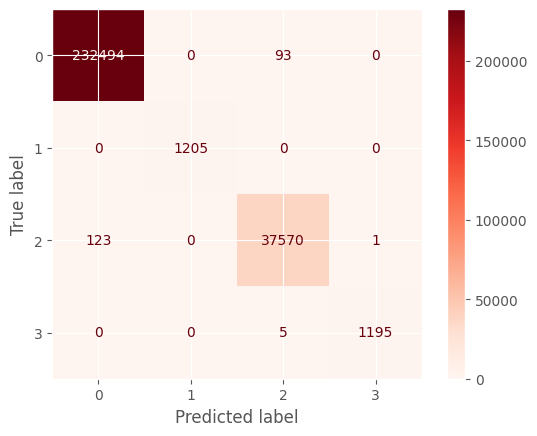

In [73]:
# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=class_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.show()

In [38]:
# View classification report
print(classification_report(y_test, y_pred, target_names=class_order, digits=4))

                  precision    recall  f1-score   support

Normal Operation     0.9995    0.9996    0.9995    232587
    Open Circuit     1.0000    1.0000    1.0000      1205
       Shadowing     0.9974    0.9967    0.9971     37694
   Short-Circuit     0.9992    0.9958    0.9975      1200

        accuracy                         0.9992    272686
       macro avg     0.9990    0.9980    0.9985    272686
    weighted avg     0.9992    0.9992    0.9992    272686



In [74]:
print(classification_report(y_test, y_pred, target_names=class_order))

                  precision    recall  f1-score   support

Normal Operation       1.00      1.00      1.00    232587
    Open Circuit       1.00      1.00      1.00      1205
       Shadowing       1.00      1.00      1.00     37694
   Short-Circuit       1.00      1.00      1.00      1200

        accuracy                           1.00    272686
       macro avg       1.00      1.00      1.00    272686
    weighted avg       1.00      1.00      1.00    272686



In [69]:
def plot_roc_curves_macro(y_true_bin, y_proba, class_names, class_colors):
    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        cls_auc = auc(fpr, tpr)

        color = class_colors.get(cls)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={cls_auc:.3f})",
                 color=color)

    plt.plot([0, 1], [0, 1], linestyle="--", color="black")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (OvR - Macro Focus)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
class_colors = {
"Normal Operation": "#2ca02c",
"Short-Circuit": "#d62728",
"Open Circuit": "#ff7f0e",
"Shadowing": "#1f77b4"
}

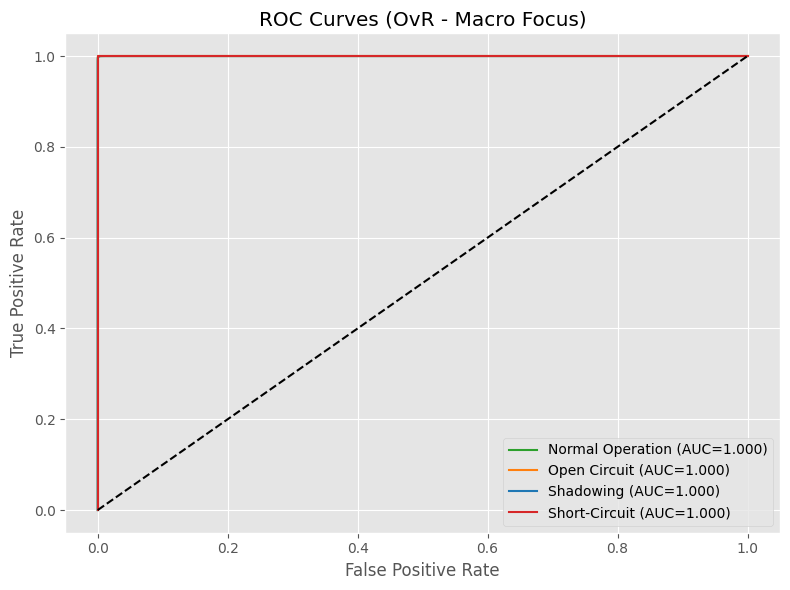

In [71]:
plot_roc_curves_macro(y_test_bin, y_proba, class_order, class_colors)

In [68]:
def plot_pr_curves_macro(y_true_bin, y_proba, class_names, class_colors):
    plt.figure(figsize=(8, 6))

    for i, cls in enumerate(class_names):
        p, r, _ = precision_recall_curve(y_true_bin[:, i], y_proba[:, i])
        ap = average_precision_score(y_true_bin[:, i], y_proba[:, i])

        color = class_colors.get(cls, None)

        plt.plot(
            r,
            p,
            label=f"{cls} (AP={ap:.3f})",
            color=color
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curves (OvR)")
    plt.legend()
    plt.tight_layout()
    plt.show()


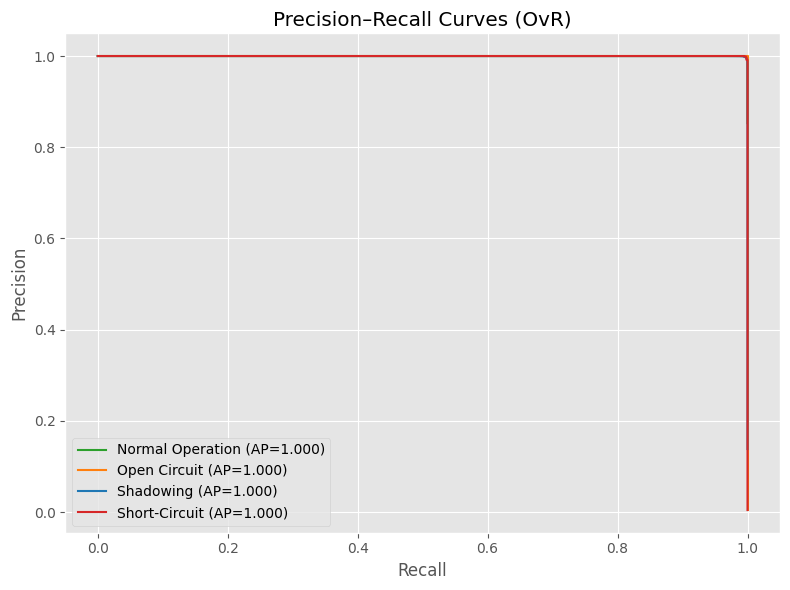

In [72]:
plot_pr_curves_macro(y_test_bin, y_proba, class_order, class_colors)

In [43]:
def plot_metrics_barchart(metrics_dict, title="Model Metrics", include_log_loss=True):
    """
    Bar chart for key evaluation metrics.
    Note: log_loss is plotted separately because lower is better.
    """
    metric_keys = [
        "accuracy",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "cohens_kappa",
        "roc_auc_macro_ovr",
        "pr_auc_macro",
    ]

    
    plt.figure(figsize=(10, 5))
    plt.bar(metric_keys, [metrics_dict[k] for k in metric_keys])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
    if include_log_loss and "log_loss" in metrics_dict:
        plt.figure(figsize=(5, 4))
        plt.bar(["log_loss"], [metrics_dict["log_loss"]])
        plt.ylabel("Log Loss (lower is better)")
        plt.title("Log Loss")
        plt.tight_layout()
        plt.show()

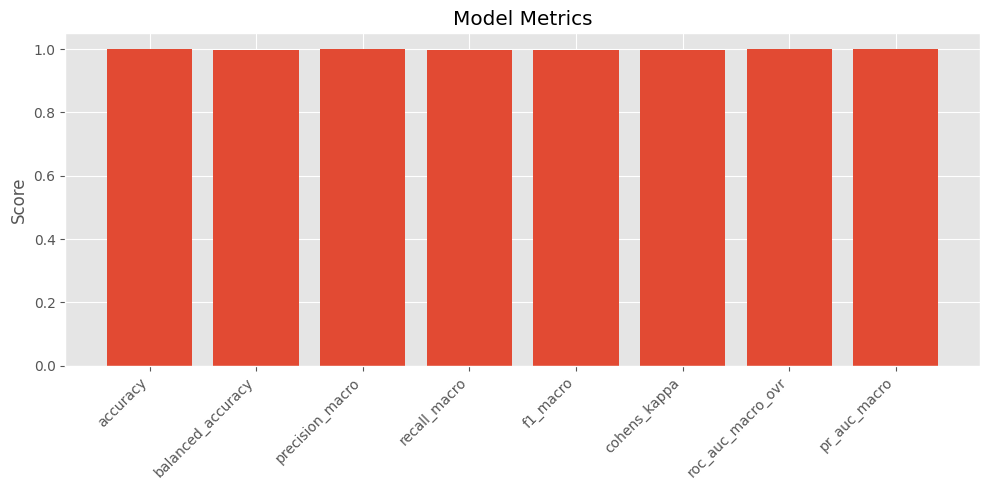

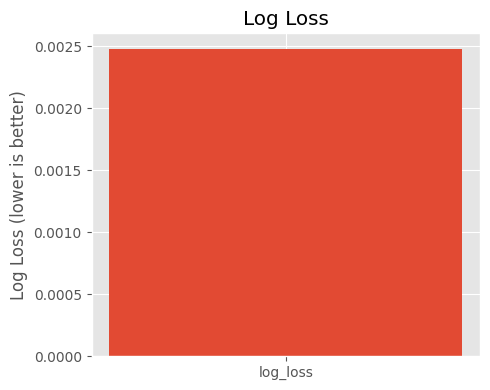

In [44]:
plot_metrics_barchart(metrics_dict)

In [ ]:
def plot_feature_importance_barchart(model, feature_names, top_n=10, title="Feature Importances"):
    """
    Bar chart for feature importances.
    """
    importances = model.feature_importances_
    fi = pd.DataFrame({"feature": feature_names, "importance": importances})
    fi = fi.sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    plt.bar(fi["feature"], fi["importance"], color="green")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.title(f"{title} (Top {top_n})")
    plt.tight_layout()
    plt.show()

    return fi 

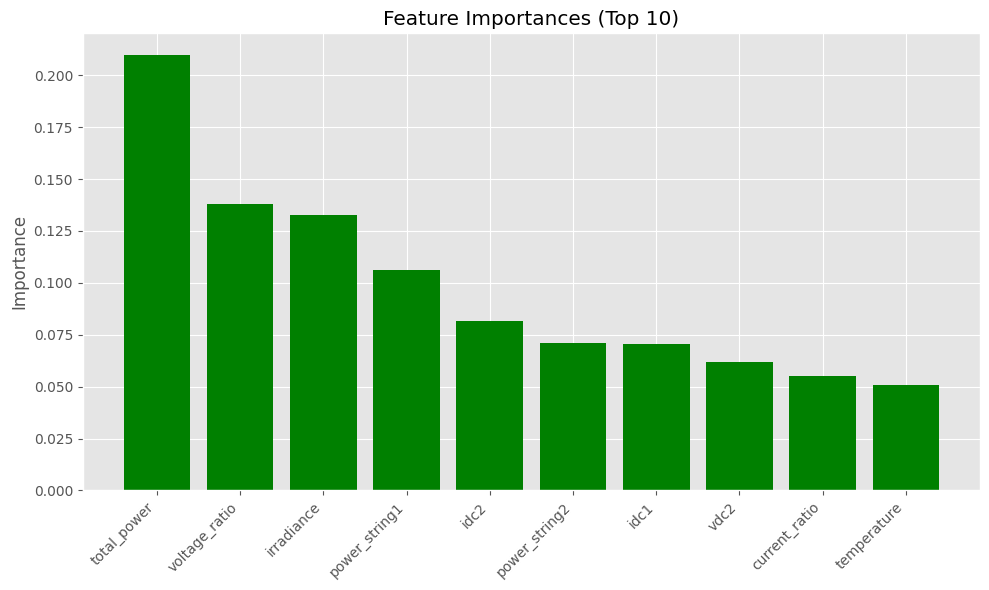

,feature,importance
8,total_power,0.209738
9,voltage_ratio,0.137810
4,irradiance,0.132700
6,power_string1,0.106222
3,idc2,0.081663
7,power_string2,0.071027
2,idc1,0.070556
1,vdc2,0.061925
10,current_ratio,0.055028
5,temperature,0.050671


In [55]:
plot_feature_importance_barchart(rf, feature_names)

In [175]:
def check_overfitting_underfitting(model, X, y):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    return acc

In [180]:
train_acc_base = check_overfitting_underfitting(rf, X_train_scaled, y_train)
test_acc_base = check_overfitting_underfitting(rf, X_test_scaled, y_test)

In [181]:
print("Base RF")
print("Train Accuracy:", train_acc_base)
print("Test  Accuracy:", test_acc_base)

Base RF
Train Accuracy: 1.0
Test  Accuracy: 0.9991858767960218


In [182]:
# Stratified to preserve class distribution across folds
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [183]:
# Scoring dictionary for metrics
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_ovr": "roc_auc_ovr"
}

In [83]:
cv_results = cross_validate(
    rf,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

In [84]:
def plot_cv_results(cv_results, scoring_dict):
    means = []
    stds = []
    labels = []

    for metric in scoring_dict.keys():
        scores = cv_results[f"test_{metric}"]
        means.append(scores.mean())
        stds.append(scores.std())
        labels.append(metric)

    plt.figure(figsize=(10, 5))
    plt.bar(labels, means, yerr=stds, capsize=5)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title("5-Fold Cross Validation (Mean ± Std)")
    plt.tight_layout()
    plt.show()

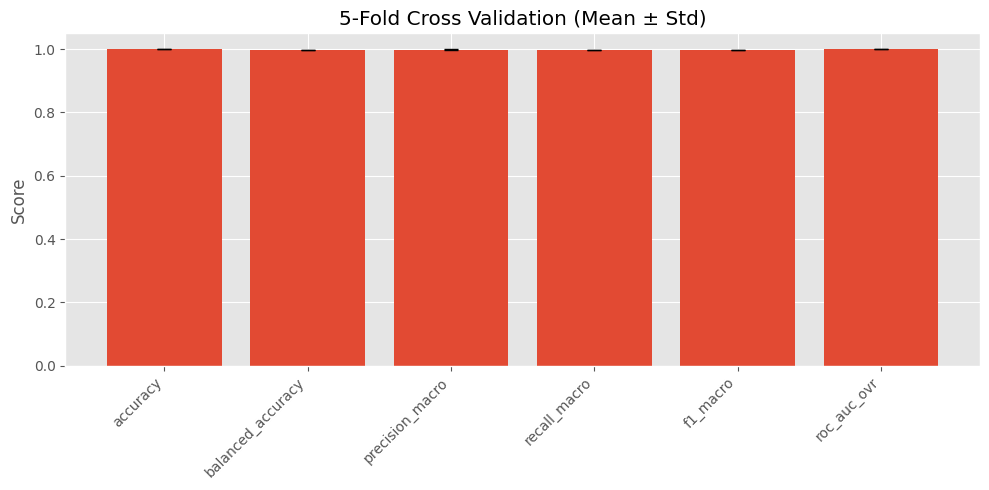

In [85]:
plot_cv_results(cv_results, scoring)

In [86]:
# Hyperparameter tuning

In [126]:
param_dist = {
    "n_estimators": [100, 200, 250],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

In [127]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [128]:
base_rf = RandomForestClassifier(class_weight=class_weights,
                                 n_jobs=-1, random_state=42)

In [129]:
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=cv,
    scoring="roc_auc_ovr",
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True  # Best model is trained automatically
)

In [130]:
random_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(class_weight={'Normal Operation': np.float64(0.2931015301866836),
                                                                  'Open Circuit': np.float64(56.585443037974684),
                                                                  'Shadowing': np.float64(1.808509474131013),
                                                                  'Short-Circuit': np.float64(56.82126484684309)},
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 3],
                                        'min_samples_split': [2, 3, 4],
                                        'n_estimators': [100, 200, 250]},
                   random_state=42, scoring='roc_auc_ovr', verbose=1)

In [160]:
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
y_proba_best = best_rf.predict_proba(X_test_scaled)

In [161]:
acc_best = accuracy_score(y_test, y_pred_best)
bacc_best = balanced_accuracy_score(y_test, y_pred_best)

In [162]:
prec_macro_best, rec_macro_best, f1_macro_best, _ = precision_recall_fscore_support(
    y_test, y_pred_best, average="macro", zero_division=0
)
kappa_best = cohen_kappa_score(y_test, y_pred_best)

In [164]:
best_class_order = best_rf.classes_

In [165]:
ll_best = log_loss(y_test, y_proba_best, labels=best_class_order)

In [171]:
y_test_bin_best = label_binarize(y_test, classes=best_class_order)
roc_auc_macro_best = roc_auc_score(y_test_bin_best, y_proba_best, average="macro", multi_class="ovr")
pr_auc_macro_best  = average_precision_score(y_test_bin_best, y_proba_best, average="macro")

In [166]:
best_metrics_dict = {
    "accuracy": float(acc_best),
    "balanced_accuracy": float(bacc_best),
    "precision_macro": float(prec_macro_best),
    "recall_macro": float(rec_macro_best),
    "f1_macro": float(f1_macro_best),
    "cohens_kappa": float(kappa_best),
    "log_loss": float(ll_best),
    "roc_auc_macro_ovr": float(roc_auc_macro_best),
    "pr_auc_macro": float(pr_auc_macro_best)
}

In [167]:
print("\nTuned Random Forest: Evaluation Metrics:")
for k, v in best_metrics_dict.items():
    print(f"{k:20s}: {v:.6f}")


Tuned Random Forest: Evaluation Metrics:
accuracy            : 0.999153
balanced_accuracy   : 0.998659
precision_macro     : 0.998524
recall_macro        : 0.998659
f1_macro            : 0.998592
cohens_kappa        : 0.996656
log_loss            : 0.002620
roc_auc_macro_ovr   : 0.999995
pr_auc_macro        : 0.999971


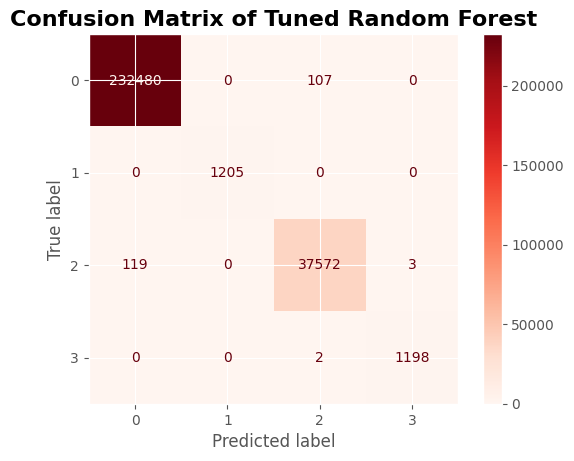

In [170]:
# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred_best, labels=best_class_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Confusion Matrix of Tuned Random Forest", fontsize=16, fontweight='bold')
plt.show()

In [157]:
print(classification_report(y_test, y_pred_best, target_names=best_class_order, digits=4))

                  precision    recall  f1-score   support

Normal Operation     0.9995    0.9995    0.9995    232587
    Open Circuit     1.0000    1.0000    1.0000      1205
       Shadowing     0.9971    0.9968    0.9969     37694
   Short-Circuit     0.9975    0.9983    0.9979      1200

        accuracy                         0.9992    272686
       macro avg     0.9985    0.9987    0.9986    272686
    weighted avg     0.9992    0.9992    0.9992    272686



In [158]:
print(classification_report(y_test, y_pred_best, target_names=best_class_order))

                  precision    recall  f1-score   support

Normal Operation       1.00      1.00      1.00    232587
    Open Circuit       1.00      1.00      1.00      1205
       Shadowing       1.00      1.00      1.00     37694
   Short-Circuit       1.00      1.00      1.00      1200

        accuracy                           1.00    272686
       macro avg       1.00      1.00      1.00    272686
    weighted avg       1.00      1.00      1.00    272686



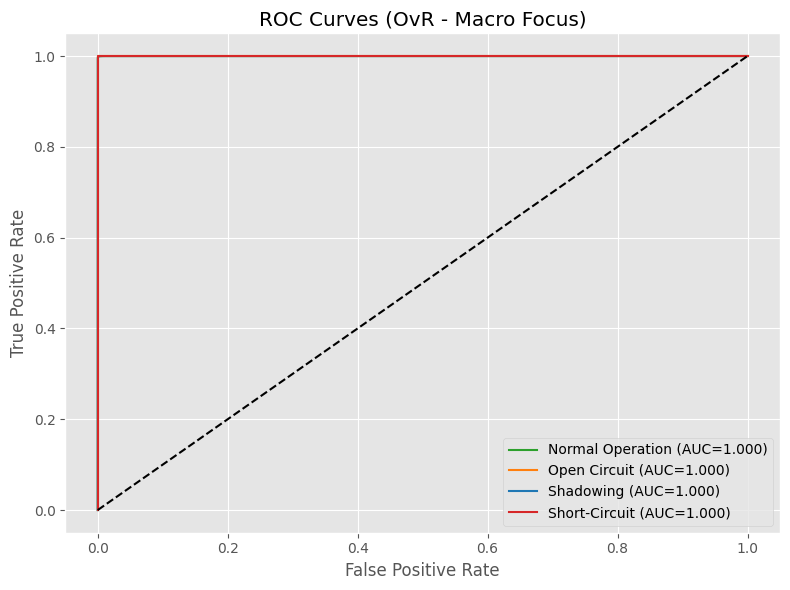

In [151]:
plot_roc_curves_macro(y_test_bin_best, y_proba_best, best_class_order, class_colors)

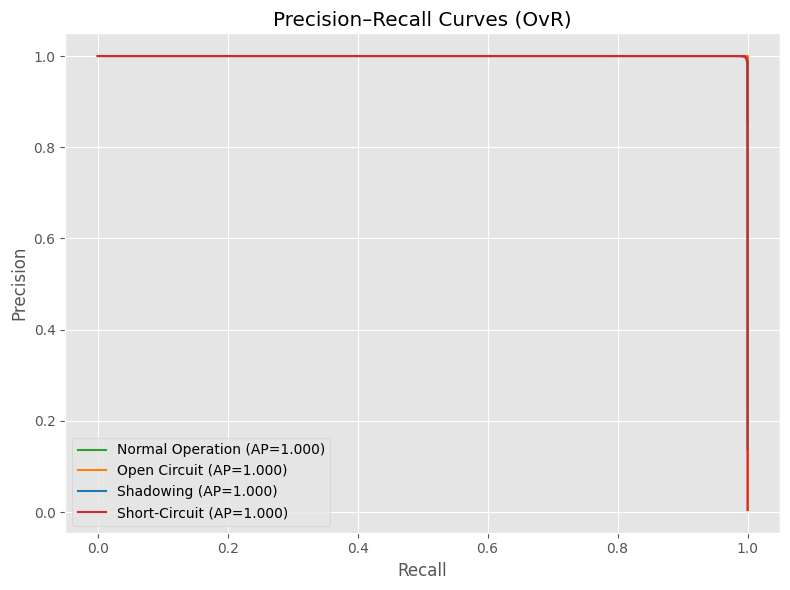

In [154]:
plot_pr_curves_macro(y_test_bin_best, y_proba_best, best_class_order, class_colors)

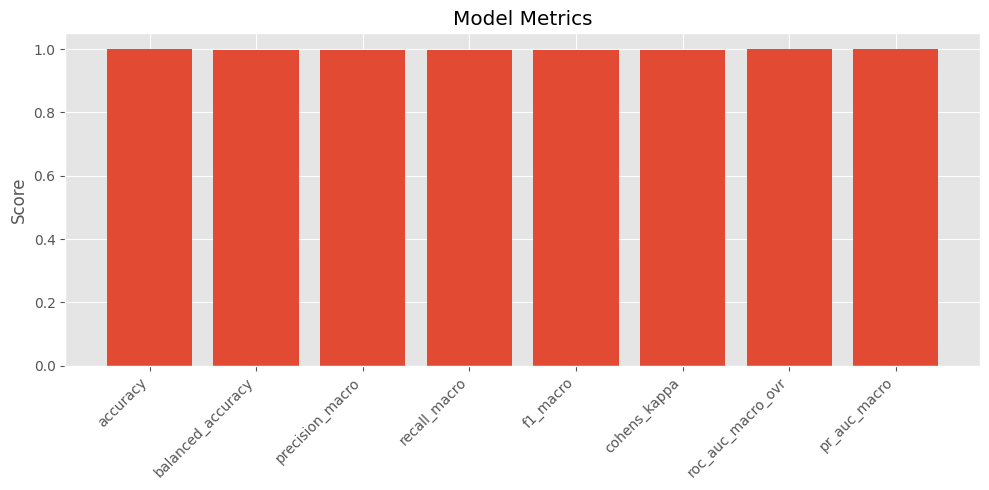

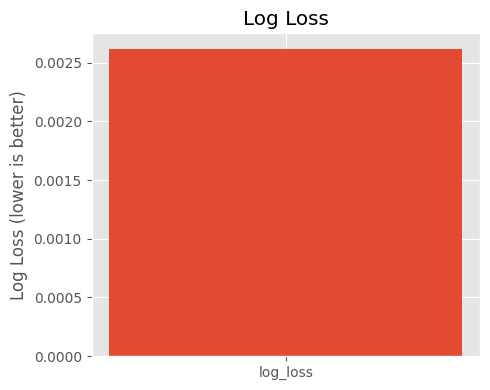

In [155]:
plot_metrics_barchart(best_metrics_dict)

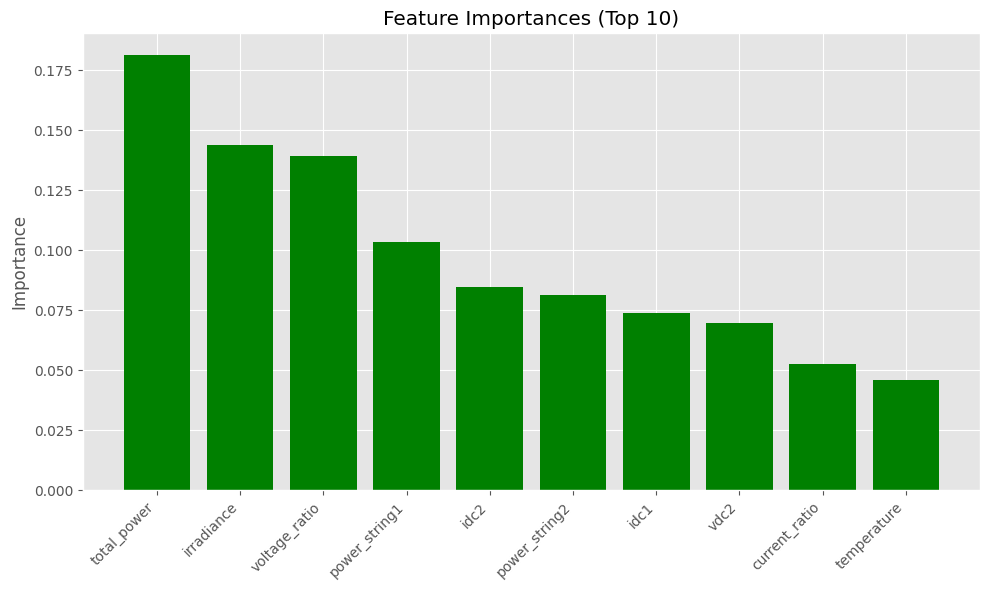

,feature,importance
8,total_power,0.181331
4,irradiance,0.143690
9,voltage_ratio,0.139228
6,power_string1,0.103457
3,idc2,0.084741
7,power_string2,0.081460
2,idc1,0.073869
1,vdc2,0.069693
10,current_ratio,0.052832
5,temperature,0.046055


In [156]:
plot_feature_importance_barchart(best_rf, feature_names)

In [173]:
def make_comparison_with_change(base_metrics, tuned_metrics, round_dp=4):
    metric_order = [
        "accuracy",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "roc_auc_macro_ovr",
        "pr_auc_macro",
        "cohens_kappa",
        "log_loss",
    ]

    base = pd.Series(base_metrics, name="Base RF")[metric_order]
    tuned = pd.Series(tuned_metrics, name="Tuned RF")[metric_order]

    df = pd.concat([base, tuned], axis=1)

    df["Δ (Tuned-Base)"] = df["Tuned RF"] - df["Base RF"]
    df["% change"] = np.where(
        df["Base RF"] != 0,
        (df["Δ (Tuned-Base)"] / df["Base RF"]) * 100,
        np.nan
    )

    return df.round(round_dp)


compare_df = make_comparison_with_change(metrics_dict, best_metrics_dict, round_dp=6)
display(compare_df)


,Base RF,Tuned RF,Δ (Tuned-Base),% change
accuracy,0.999186,0.999153,-0.000033,-0.003303
balanced_accuracy,0.998036,0.998659,0.000623,0.062444
precision_macro,0.999008,0.998524,-0.000484,-0.048440
recall_macro,0.998036,0.998659,0.000623,0.062444
f1_macro,0.998521,0.998592,0.000070,0.007043
roc_auc_macro_ovr,0.999996,0.999995,-0.000001,-0.000114
pr_auc_macro,0.999979,0.999971,-0.000008,-0.000809
cohens_kappa,0.996785,0.996656,-0.000130,-0.013009
log_loss,0.002479,0.002620,0.000140,5.652405


In [179]:
# Tuned RF
train_acc_best = check_overfitting_underfitting(best_rf, X_train_scaled, y_train)
test_acc_best  = check_overfitting_underfitting(best_rf, X_test_scaled, y_test)

print("\nTuned RF")
print("Train Accuracy:", train_acc_best)
print("Test  Accuracy:", test_acc_best)



Tuned RF
Train Accuracy: 0.9999899151127536
Test  Accuracy: 0.9991528718012659


In [178]:
pipeline = Pipeline([
    ("scaler", scaler),
    ("model", best_rf)
])